# chap 4

목차
1. 부스팅
2. 그레이디언트 부스팅 작동방식
3. 매개변수 튜닝
4. 그레이디언트 부스팅 vs XGBoost

## 1. 부스팅

부스팅 기법이 배깅과 다른 점은 이전 트리의 오차에서 배운다는 점이다. 즉, 개별 트리는 독립적이지 않고 이전 트리의 영향을 받아 만들어 진다.

### 1. Adaboost

에이다부스트는 부스팅 기법 초기 모델이다. 이전 모델이 잘못 예측한 데이터에 가중치를 부여하여 다음 모델이 해당 데이터에 더 집중하게 하는 알고리즘이다.
- 작동 방식:
1. 첫 번째 약한 학습기(Weak Learner)를 만든다. 주로 깊이가 1인 트리(Stump)
2. 오분류 데이터의 가중치는 높이고, 정분류 데이터의 가중치는 낮춘다.
3. 다음 학습기는 가증치가 업데이트된 데이터를 바탕으로 학습한다.
4. 정해진 횟수만큼 반복 후, 각 학습기의 정확도에 따라 가중치를 두어 Voting해 결과를 도출한다.

### 2. Gradient Boosting(GBM)

현대 머신러닝에서는 Gradient Boosting 기반의 알고리즘이 주류로 사용된다.
- 작동 방식:
1. 일반적으로 타깃변수의 평균을 통해 첫 예측을 수행한다.
2. 실제값과 예측값의 잔차(Residual)을 계산한다.
3. 다음 학습기는 평균이 아닌 잔차를 이용해 학습한다.
4. 학습된 모델을 이전 예측값에 더하여 모델을 업데이트 한다.
5. 이 과정을 반복에 잔차를 0에 가깝게 한다.

## 2. 그레이디언트 부스팅 작동방식

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
xgb.set_config(verbosity=1)
# 0 (Silent): 아무런 메시지도 출력하지 않습니다. (단, 치명적인 오류는 출력됩니다.)
# 1 (Warning): 기본값(Default)입니다. 위험하거나 주의해야 할 경고 메시지만 출력합니다.
# 2 (Info): 트리가 어떻게 분할되고 있는지 등 학습 진행 상황에 대한 유용한 정보를 출력합니다.
# 3 (Debug): 문제 해결을 위한 매우 상세한 디버깅용 정보를 모두 출력합니다.

from pathlib import Path
parent_path = Path.cwd().parents[2]
data_dir = parent_path / "04_Resources" / "Dataset" / "XGBoost"

In [2]:
df_bikes = pd.read_csv(data_dir / 'bike_rentals_cleaned.csv')
df_bikes.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1.0,0.0,1,0.0,6.0,0.0,2,0.344167,0.363625,0.805833,0.160446,985
1,2,1.0,0.0,1,0.0,0.0,0.0,2,0.363478,0.353739,0.696087,0.248539,801
2,3,1.0,0.0,1,0.0,1.0,1.0,1,0.196364,0.189405,0.437273,0.248309,1349
3,4,1.0,0.0,1,0.0,2.0,1.0,1,0.200000,0.212122,0.590435,0.160296,1562
4,5,1.0,0.0,1,0.0,3.0,1.0,1,0.226957,0.229270,0.436957,0.186900,1600


In [3]:
# 타겟 변수 분리
y_bikes = df_bikes['cnt']
X_bikes = df_bikes.drop(['cnt'], axis=1)

# train/test 세트 분리
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_bikes, y_bikes, random_state=2
)

1. 결정 트리를 훈련한다. 이때 결정 트리의 깊이는 1~3 정도로 함

In [4]:
# 모델 생성
from sklearn.tree import DecisionTreeRegressor
tree_1 = DecisionTreeRegressor(max_depth=2, random_state=2)
tree_1.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=2, random_state=2)

2. test 데이터가 아닌 train 데이터에 대한 예측을 생성한다. 지금 필요한 정보는 첫 모델의 잔차이기 때문이다. test 데이터 예측은 트리를 모두 구성한 후 마지막 단계에서 한다.

In [5]:
y_train_pred = tree_1.predict(X_train)

3. 잔차를 계산한다. 잔차는 다음 트리의 타겟 데이터가 된다

In [6]:
y2_train = y_train - y_train_pred

4. 새로운 트리를 학습한다

In [7]:
tree_2 = DecisionTreeRegressor(max_depth=2, random_state=2)
tree_2.fit(X_train, y2_train)

DecisionTreeRegressor(max_depth=2, random_state=2)

5. 2~4 단계를 반복하면서 잔차가 0에 가까워짐.

In [8]:
y2_train_pred = tree_2.predict(X_train)
y3_train = y2_train - y2_train_pred
tree_3 = DecisionTreeRegressor(max_depth=2, random_state=2)
tree_3.fit(X_train, y3_train)

DecisionTreeRegressor(max_depth=2, random_state=2)

6. 결과를 더한다.

In [9]:
y1_pred = tree_1.predict(X_test)
y2_pred = tree_2.predict(X_test)
y3_pred = tree_3.predict(X_test)
y_pred = y1_pred + y2_pred + y3_pred

7. rmse를 계산한다

In [10]:
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_test, y_pred)

911.0479538776444

### 사이킷런 클래스 사용

In [13]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(max_depth=2, n_estimators=3, random_state=2, learning_rate=1.0)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
root_mean_squared_error(y_test, y_pred) # 방금 전에 구현한것과 동일한 결과

911.0479538776439

In [ ]:
# 트리 개수를 늘려보자
gbr = GradientBoostingRegressor(max_depth=2, n_estimators=30, random_state=2, learning_rate=1.0)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
root_mean_squared_error(y_test, y_pred)

857.1072323426944

In [18]:
# 개수를 더 늘리고 학습률을 기본값(0.1)으로
gbr = GradientBoostingRegressor(max_depth=2, n_estimators=300, random_state=2, learning_rate=0.1)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
root_mean_squared_error(y_test, y_pred)

654.0458249598231

성능이 큰 폭으로 늘었다. 학습률에 대한 내용은 경사 하강법을 따로 살펴보면 된다.

## 3. 매개변수 튜닝

### learning_rate

일반적으로 n_estimators를 늘리면 learning_rate는 줄이는게 좋다.

In [19]:
learning_rate_list = [0.0001, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0]
for i in learning_rate_list:
    gbr = GradientBoostingRegressor(max_depth=2, n_estimators=300, random_state=2, learning_rate=i)
    gbr.fit(X_train, y_train)
    y_pred = gbr.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    print(f'학습률: {i}, 점수: {rmse}')

학습률: 0.0001, 점수: 1942.442647403738
학습률: 0.01, 점수: 831.5430182728547
학습률: 0.05, 점수: 685.0192988749716
학습률: 0.1, 점수: 654.0458249598231
학습률: 0.15, 점수: 684.7722396571845
학습률: 0.2, 점수: 669.5171947704456
학습률: 0.3, 점수: 689.3206465434059
학습률: 0.5, 점수: 685.9250681550302
학습률: 1.0, 점수: 964.6148916460602


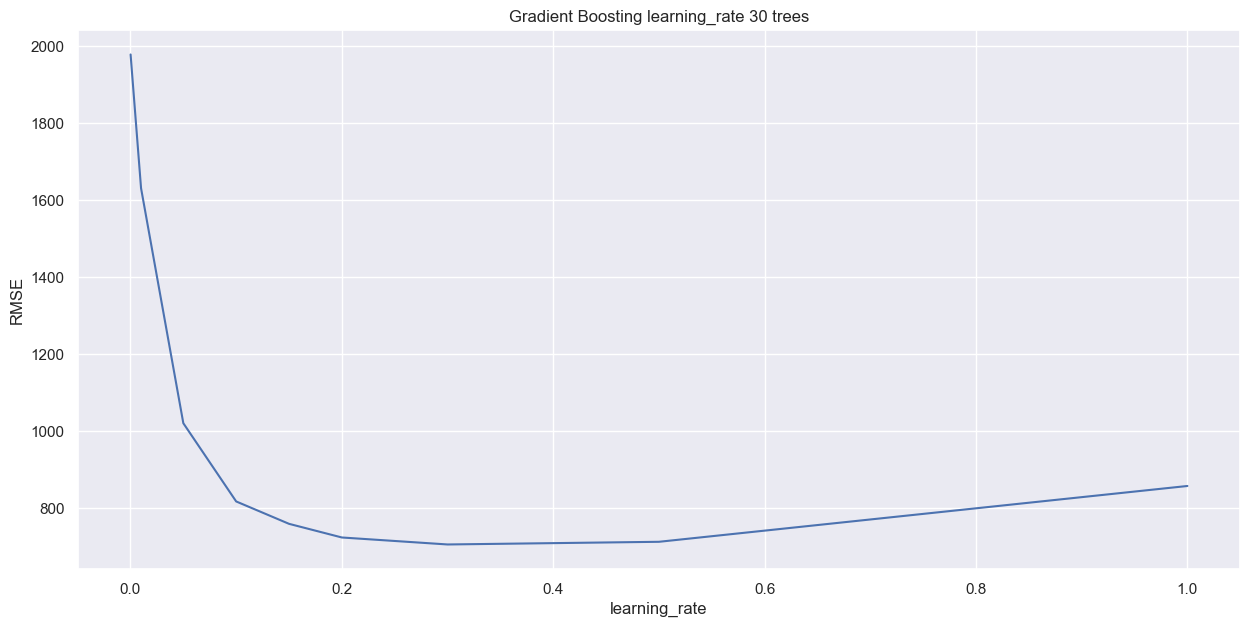

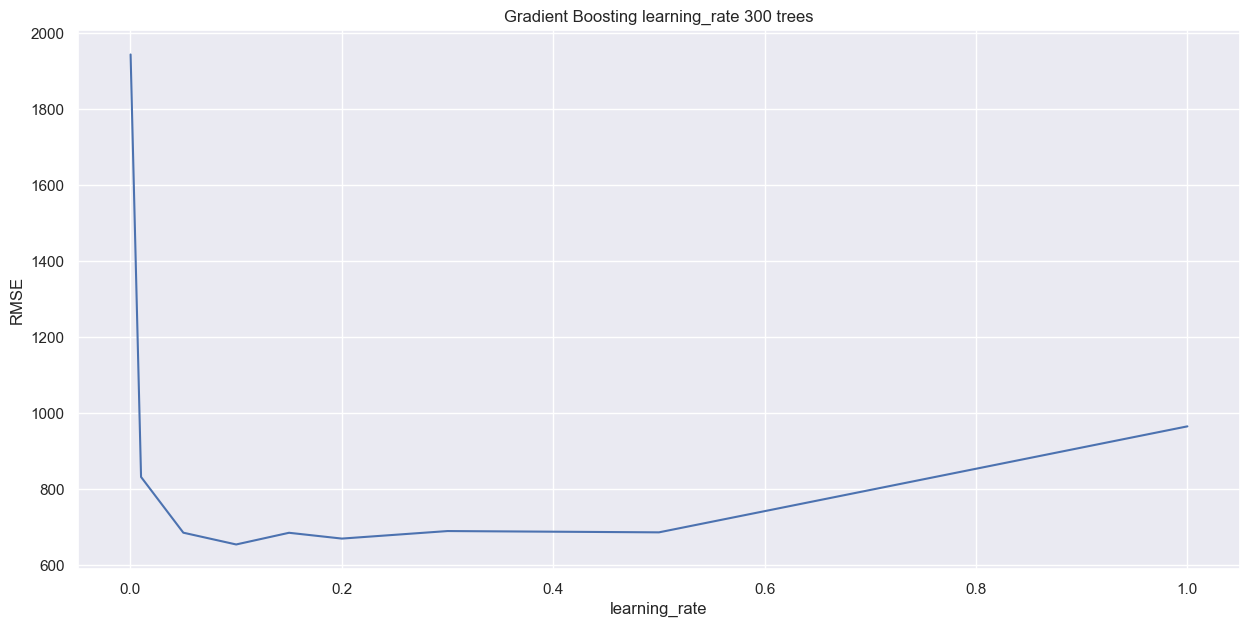

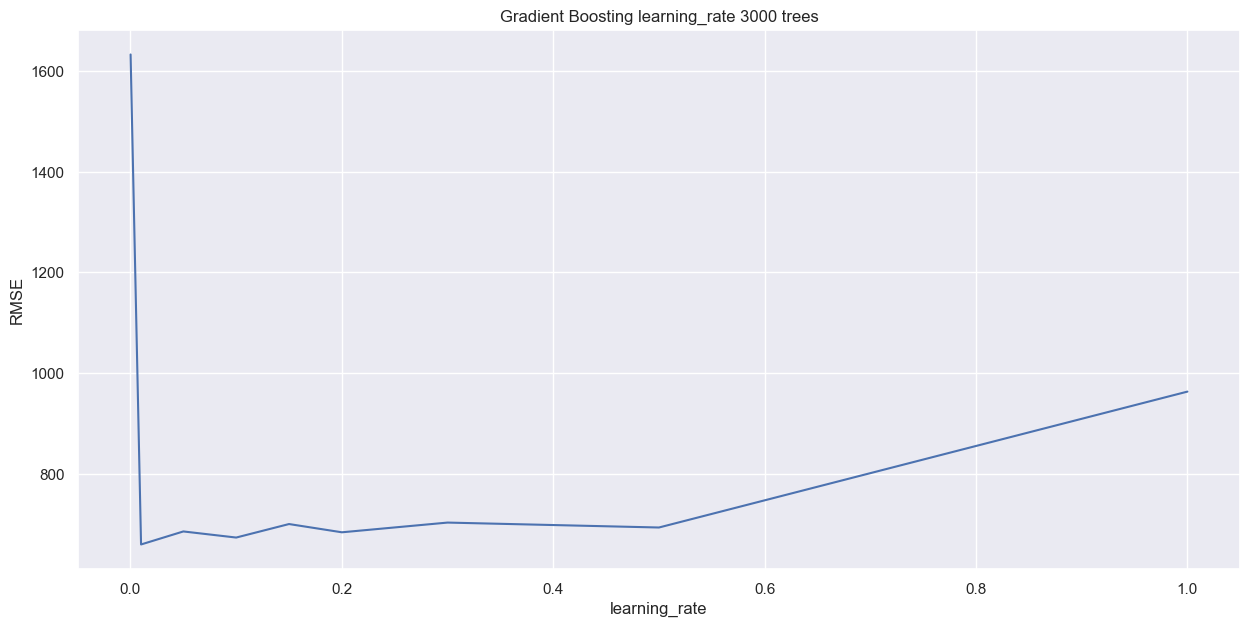

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
from sklearn.metrics import mean_squared_error

for est in [30, 300, 3000]:
    rmse_scores = []
    for value in learning_rate_list:
        gbr = GradientBoostingRegressor(max_depth=2, n_estimators=est, 
                                        random_state=2, learning_rate=value)
        gbr.fit(X_train, y_train)
        y_pred = gbr.predict(X_test)
        rmse = root_mean_squared_error(y_test, y_pred)
        rmse_scores.append(rmse)
    plt.figure(figsize=(15,7))
    plt.plot(learning_rate_list, rmse_scores)
    plt.xlabel('learning_rate')
    plt.ylabel('RMSE')
    plt.title('Gradient Boosting learning_rate {} trees'.format(est))
    plt.show()

### 기본 학습기

기본 학습기로는 Decision Tree를 사용했다. 성능을 위해 기본 학습기의 파라미터를 튜닝할 수 있다.

In [32]:
depths = [None, 1, 2, 3]
for depth in depths:
    gbr = GradientBoostingRegressor(max_depth=depth, n_estimators=300, random_state=2)
    gbr.fit(X_train, y_train)
    y_pred = gbr.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    print(f"최대 깊이: {depth}, 점수: {rmse}")

최대 깊이: None, 점수: 873.0695181432386
최대 깊이: 1, 점수: 707.6085069770935
최대 깊이: 2, 점수: 654.0458249598231
최대 깊이: 3, 점수: 643.3469183945178


In [33]:
len(gbr.estimators_)

300

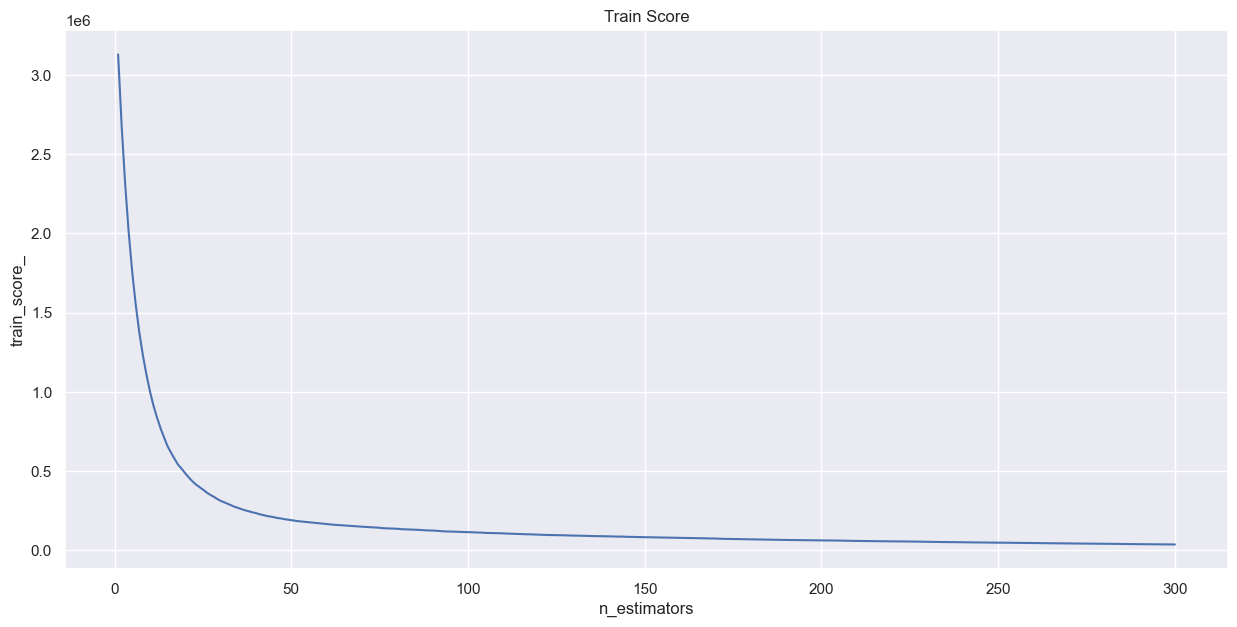

In [34]:
plt.figure(figsize=(15,7))
plt.plot(range(1, 301), gbr.train_score_)
plt.xlabel('n_estimators')
plt.ylabel('train_score_')
plt.title('Train Score')
plt.show()

깊이가 3일 때 점수가 가장 잘 나왔다. 나머지 파라미터도 chap2를 참고해서 튜닝할 수 있다.

### subsample

기본 학습기에 사용될 샘플의 비율 지정

In [30]:
samples = [1, 0.9, 0.8, 0.7, 0.6, 0.5]
for sample in samples:
    gbr = GradientBoostingRegressor(max_depth=3, n_estimators=300, subsample=sample, random_state=2)
    gbr.fit(X_train,y_train)
    y_pred = gbr.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    print(f"subsample: {sample}, 점수: {rmse}")

subsample: 1, 점수: 643.3469183945178
subsample: 0.9, 점수: 616.6481382179303
subsample: 0.8, 점수: 598.2243848632102
subsample: 0.7, 점수: 608.9922726459009
subsample: 0.6, 점수: 627.9341542693314
subsample: 0.5, 점수: 623.9933416212008


0.7일 때 성능이 가장 좋다. 이렇게 subsample이 1보다 작은 모델을 확률적 그레이디언트 부스팅이라고 한다.

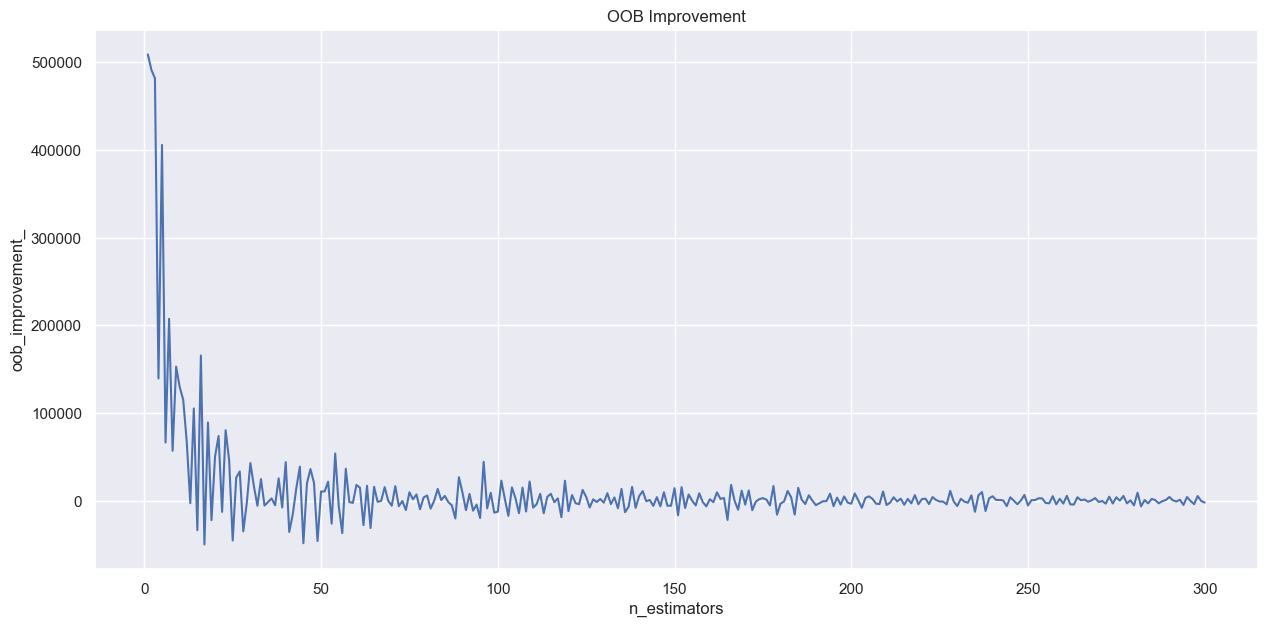

In [31]:
plt.figure(figsize=(15,7))
plt.plot(range(1, 301), gbr.oob_improvement_)
plt.xlabel('n_estimators')
plt.ylabel('oob_improvement_')
plt.title('OOB Improvement')
plt.show()

### RandomizedSearchCV 사용

앞서 탐색한 파라미터를 기준으로 범위를 좁혀 사용해보자

In [35]:
from sklearn.model_selection import RandomizedSearchCV

params = {'subsample':[0.65, 0.7, 0.75],
          'n_estimators':[300, 500, 1000],
          'learning_rate':[0.05, 0.075, 0.1]}

gbt = GradientBoostingRegressor(max_depth=3, random_state=2)

rand_reg = RandomizedSearchCV(gbr, params, n_iter=10,
                              scoring='neg_root_mean_squared_error',
                              cv=5, n_jobs=-1, random_state=2)

rand_reg.fit(X_train, y_train)
best_model = rand_reg.best_estimator_
best_params = rand_reg.best_params_
best_score = -rand_reg.best_score_
test_score = root_mean_squared_error(y_test ,best_model.predict(X_test))
print(f"best params: {best_params}")
print(f"best score: {best_score}")
print(f"test score: {test_score}")

best params: {'subsample': 0.75, 'n_estimators': 300, 'learning_rate': 0.1}
best score: 631.9443715884895
test score: 611.1713679747425


다양한 매개변수를 사용해서 튜닝을 해보자

In [37]:
from scipy.stats import loguniform, randint

params = {'subsample': loguniform(7e-1,8e-1),
          'n_estimators':randint(1590, 1610),
          'learning_rate':loguniform(9e-3, 5e-2)}

gbt = GradientBoostingRegressor(max_depth=3, random_state=2)

rand_reg = RandomizedSearchCV(gbr, params, n_iter=10,
                              scoring='neg_root_mean_squared_error',
                              cv=5, n_jobs=-1, random_state=2)

rand_reg.fit(X_train, y_train)
best_model = rand_reg.best_estimator_
best_params = rand_reg.best_params_
best_score = -rand_reg.best_score_
test_score = root_mean_squared_error(y_test ,best_model.predict(X_test))
print(f"best params: {best_params}")
print(f"best score: {best_score}")
print(f"test score: {test_score}")

best params: {'learning_rate': np.float64(0.010984362777185307), 'n_estimators': 1592, 'subsample': np.float64(0.7119873775899093)}
best score: 625.3554852026714
test score: 610.5416346676725


In [38]:
gbr = GradientBoostingRegressor(max_depth=3, n_estimators=1600, 
                                subsample=0.75, learning_rate=0.02, 
                                random_state=2)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
root_mean_squared_error(y_test, y_pred)

600.0791039723779

### XGBoost 사용해보기

동일안 매개변수로 학습하고 결과를 비교해보자

In [41]:
from xgboost import XGBRegressor
xg_reg = XGBRegressor(max_depth=3, n_estimators=1600, 
                                subsample=0.75, learning_rate=0.02, 
                                random_state=2)
xg_reg.fit(X_train, y_train)
y_pred = xg_reg.predict(X_test)
root_mean_squared_error(y_test, y_pred)

586.6243896484375

더 좋은 성능을 보여준다.

## 4. 그레이디언트 부스팅 vs XGBoost

이제 본격적으로 대용량 데이터 연산을 해보자. 2017년 캐글에서 나온 데이터셋인데, 5087행 3198열로 구성된 회계 행성 데이터이다.

https://www.kaggle.com/datasets/keplersmachines/kepler-labelled-time-series-data

각 행은 하나의 별에 대한 정보이고 각 열은 시간에 따른 밝기의 변화, 추가로 LABEL열은 외계행성을 가지면 2, 아니면 1로 표시되어있다.

목표는 외계 행성을 가진 별을 찾는 것이다.

In [42]:
df = pd.read_csv(data_dir / "exoplanets.csv")
df.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


In [44]:
df.info() # 모든 자료가 실수형임을 알 수 있다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5087 entries, 0 to 5086
Columns: 3198 entries, LABEL to FLUX.3197
dtypes: float64(3197), int64(1)
memory usage: 124.1 MB


In [47]:
df.isna().sum().sum() # 결측치가 없다.

np.int64(0)

In [53]:
# 데이터셋 분리
y = df['LABEL']
X = df.drop('LABEL', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=2
)

In [49]:
# 두 모델을 사용하여 비교해보자
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# time 패키지로 모델 시간을 측정해보자
import time
start = time.time()
df.info()
end = time.time()
elapsed = end-start
elapsed

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5087 entries, 0 to 5086
Columns: 3198 entries, LABEL to FLUX.3197
dtypes: float64(3197), int64(1)
memory usage: 124.1 MB


0.040724992752075195

In [ ]:
# GradientBoostingClassifier
start = time.time()
clf = GradientBoostingClassifier(n_estimators=100, max_depth=2, random_state=2)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
score = accuracy_score(y_test, y_pred)
end = time.time()
elapsed = end - start
print(f"accuracy: {score}")
print(f"elapsed: {elapsed}")


accuracy: 0.9874213836477987
elapsed: 236.3642041683197


In [ ]:
# xgboost

# xgboost는 라벨 형태가 0, 1, 2 ... 형태여야 하는데 이 테이터셋은 1부터 시작하므로 변환
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train) # fit(): 데이터를 분석하여 변환 기준 마련 transform():  fit한 기준으로 데이터 변환
y_test = le.transform(y_test) # test데이터에는 학습을 하면 안되므로 그냥 transform. train에서 fit한 기준 그대로 적용! 2->1, 1->0

start = time.time()
xg_clf = XGBClassifier(n_estimators=100, max_depth=2)
xg_clf.fit(X_train, y_train)
y_pred = xg_clf.predict(X_test)
score = accuracy_score(y_test, y_pred)
end = time.time()
elapsed = end - start
print(f"accuracy: {score}")
print(f"elapsed: {elapsed}")

accuracy: 0.9913522012578616
elapsed: 4.155916213989258


엄청난 시간 절약과 점수 향상이 있다